# Lecture 01 — Introduction to Reinforcement Learning
**David Silver's UCL RL Course · Implemented from Scratch**

*Reference: Sutton & Barto (2018), Chapter 1*

---

This notebook implements the core concepts from Lecture 1:
the agent-environment loop, reward, state, the Markov property,
and the policy/value function — all visualized on the gridworld
from Silver's slides.

**Contents:**
1. [Setup](#1)
2. [The GridWorld Environment](#2)
3. [The Agent-Environment Loop](#3)
4. [Policy — What Should the Agent Do?](#4)
5. [Value Function — How Good Is Each State?](#5)
6. [The Discount Factor γ](#6)
7. [Exploration vs. Exploitation](#7)
8. [Key Takeaways](#8)

<a id='1'></a>
## 1. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import os

np.random.seed(42)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 12,
})

BLUE   = '#2563EB'
RED    = '#DC2626'
GREEN  = '#16A34A'
ORANGE = '#D97706'
GRAY   = '#6B7280'
BLACK  = '#111827'

print('Setup complete.')

Setup complete.


<a id='2'></a>
## 2. The GridWorld Environment

The **gridworld** is the simplest useful RL environment — a 2D grid where the agent
moves up/down/left/right. Black cells are walls. The agent starts at the top-left
and tries to reach the goal at the bottom-right.

This is exactly the maze from Silver's slides (Lecture 1, slides 30–33).

**MDP components:**
- **States** $S$: each grid cell $(row, col)$
- **Actions** $A$: \{North, East, South, West\}
- **Rewards** $R$: $-1$ per time step (agent wants to reach goal quickly)
- **Transitions** $P$: deterministic — action moves agent one step if no wall
- **Terminal state**: the goal cell

In [4]:
class GridWorld:
    """A simple rectangular gridworld with walls, matching Silver's Lecture 1 maze.

    States are (row, col) tuples.
    Actions: 0=North, 1=East, 2=South, 3=West.
    Reward: -1 per step.  +0 at terminal state.
    """

    # Action definitions: (row_delta, col_delta)
    ACTIONS = {
        0: (-1,  0),   # North
        1: ( 0,  1),   # East
        2: ( 1,  0),   # South
        3: ( 0, -1),   # West
    }
    ACTION_NAMES  = {0: 'N', 1: 'E', 2: 'S', 3: 'W'}
    ACTION_ARROWS = {0: '↑', 1: '→', 2: '↓', 3: '←'}
    N_ACTIONS = 4

    def __init__(self, grid, start, goal, step_reward=-1):
        """Initialise the gridworld.

        Parameters
        ----------
        grid : list[list[int]]
            2D list.  0 = passable cell, 1 = wall.
        start : tuple (row, col)
        goal  : tuple (row, col)
        step_reward : float, default -1
        """
        self.grid         = np.array(grid)
        self.nrows, self.ncols = self.grid.shape
        self.start        = start
        self.goal         = goal
        self.step_reward  = step_reward
        self.state        = start

        # Pre-compute all valid (non-wall) states
        self.states = [
            (r, c)
            for r in range(self.nrows)
            for c in range(self.ncols)
            if self.grid[r, c] == 0
        ]
        self.n_states = len(self.states)
        self.state_index = {s: i for i, s in enumerate(self.states)}

    def reset(self):
        """Reset environment to start state."""
        self.state = self.start
        return self.state

    def is_terminal(self, state):
        """Return True if state is the goal."""
        return state == self.goal

    def step(self, action):
        """Take an action.  Returns (next_state, reward, done)."""
        if self.is_terminal(self.state):
            return self.state, 0.0, True

        dr, dc    = self.ACTIONS[action]
        nr, nc    = self.state[0] + dr, self.state[1] + dc

        # Stay in place if hitting wall or boundary
        if (0 <= nr < self.nrows and
            0 <= nc < self.ncols and
            self.grid[nr, nc] == 0):
            self.state = (nr, nc)

        done   = self.is_terminal(self.state)
        reward = 0.0 if done else self.step_reward
        return self.state, reward, done

    def transition(self, state, action):
        """Return next_state for a given (state, action) — no side effects."""
        if self.is_terminal(state):
            return state
        dr, dc = self.ACTIONS[action]
        nr, nc = state[0] + dr, state[1] + dc
        if (0 <= nr < self.nrows and
            0 <= nc < self.ncols and
            self.grid[nr, nc] == 0):
            return (nr, nc)
        return state


# ── Build Silver's maze ─────────────────────────────────────────────────────
# 0 = open cell, 1 = wall
# Matches the maze layout in Silver's slides (6x7 grid)
SILVER_MAZE = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

env = GridWorld(
    grid  = SILVER_MAZE,
    start = (0, 0),
    goal  = (5, 6),
)

print(f'Grid size:     {env.nrows} × {env.ncols}')
print(f'Valid states:  {env.n_states}')
print(f'Start:         {env.start}')
print(f'Goal:          {env.goal}')
print(f'Actions:       {env.ACTION_NAMES}')

Grid size:     6 × 7
Valid states:  36
Start:         (0, 0)
Goal:          (5, 6)
Actions:       {0: 'N', 1: 'E', 2: 'S', 3: 'W'}


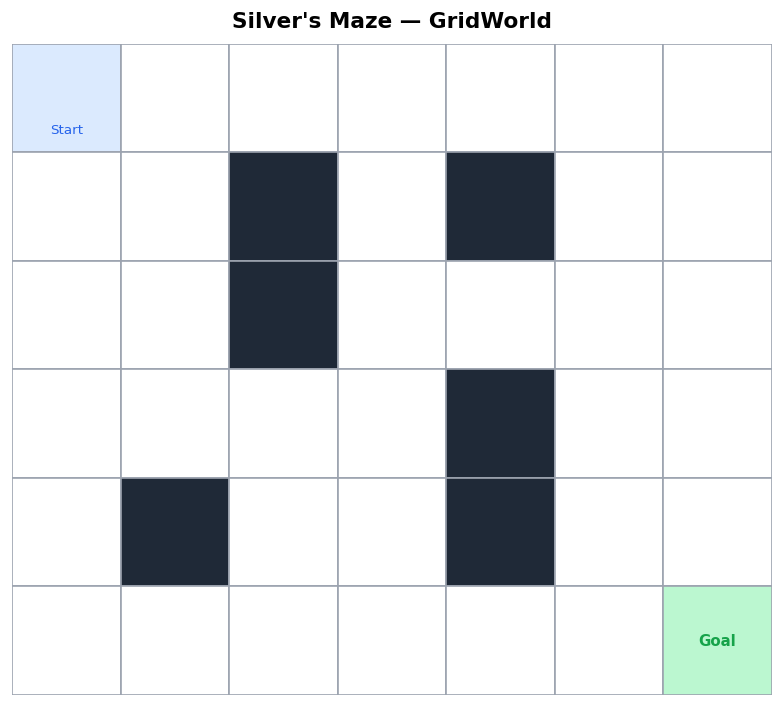

✓ Saved: figures/01_maze.png


In [5]:
def render_grid(env, values=None, policy=None, title='GridWorld',
                cmap='RdYlGn', figsize=(7, 6)):
    """Render the gridworld with optional value function heatmap and policy arrows."""
    fig, ax = plt.subplots(figsize=figsize)

    # Background
    for r in range(env.nrows):
        for c in range(env.ncols):
            if env.grid[r, c] == 1:          # wall
                color = '#1f2937'
            elif (r, c) == env.goal:          # goal
                color = '#bbf7d0'
            elif (r, c) == env.start:         # start
                color = '#dbeafe'
            else:
                color = 'white'
            rect = plt.Rectangle((c, env.nrows-1-r), 1, 1,
                                   facecolor=color, edgecolor='#9ca3af', lw=1)
            ax.add_patch(rect)

    # Value function heatmap
    if values is not None:
        all_v = [v for (r,c), v in values.items()
                 if env.grid[r,c]==0 and (r,c)!=env.goal]
        vmin, vmax = min(all_v), max(all_v)
        norm   = Normalize(vmin=vmin, vmax=vmax)
        cmap_fn = cm.get_cmap(cmap)
        for (r, c), v in values.items():
            if env.grid[r, c] == 1:
                continue
            color = cmap_fn(norm(v)) if (r,c)!=env.goal else '#bbf7d0'
            rect  = plt.Rectangle((c, env.nrows-1-r), 1, 1,
                                    facecolor=color, edgecolor='#9ca3af', lw=1)
            ax.add_patch(rect)
            ax.text(c + 0.5, env.nrows-1-r + 0.5, f'{v:.1f}',
                    ha='center', va='center', fontsize=9, fontweight='bold',
                    color='black')

    # Policy arrows
    if policy is not None and values is None:
        for (r, c), action in policy.items():
            if env.is_terminal((r, c)) or env.grid[r, c] == 1:
                continue
            arrow = env.ACTION_ARROWS[action]
            ax.text(c + 0.5, env.nrows-1-r + 0.5, arrow,
                    ha='center', va='center', fontsize=16,
                    color=RED, fontweight='bold')

    # Labels
    ax.text(env.start[1]+0.5, env.nrows-1-env.start[0]+0.15,
            'Start', ha='center', va='bottom', fontsize=8, color=BLUE)
    ax.text(env.goal[1]+0.5, env.nrows-1-env.goal[0]+0.5,
            'Goal', ha='center', va='center', fontsize=9,
            color=GREEN, fontweight='bold')

    ax.set_xlim(0, env.ncols)
    ax.set_ylim(0, env.nrows)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    plt.tight_layout()
    return fig, ax


fig, _ = render_grid(env, title="Silver's Maze — GridWorld")
plt.savefig('figures/01_maze.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/01_maze.png')

<a id='3'></a>
## 3. The Agent-Environment Loop

The core RL loop:

```
for each time step t:
    agent observes state Sₜ
    agent selects action Aₜ = π(Sₜ)
    environment returns reward Rₜ₊₁ and next state Sₜ₊₁
```

We simulate this with a **random policy** — the agent picks actions uniformly at random.
This is the baseline we'll improve upon in later lectures.

In [6]:
def run_episode(env, policy_fn, max_steps=200, gamma=1.0):
    """Run one episode.  Returns trajectory and total return G.

    Parameters
    ----------
    env       : GridWorld
    policy_fn : callable(state) -> action
    max_steps : int
    gamma     : float, discount factor

    Returns
    -------
    trajectory : list of (state, action, reward)
    G          : float, total discounted return
    """
    state      = env.reset()
    trajectory = []
    G          = 0.0
    discount   = 1.0

    for t in range(max_steps):
        if env.is_terminal(state):
            break
        action               = policy_fn(state)
        next_state, reward, done = env.step(action)
        trajectory.append((state, action, reward))
        G       += discount * reward
        discount *= gamma
        state    = next_state

    return trajectory, G


def random_policy(state):
    """Uniform random policy — pick any action with equal probability."""
    return np.random.randint(env.N_ACTIONS)


# Run 5 episodes and inspect
print('=== Random Policy Episodes ===')
print(f'{"Episode":>8}  {"Steps":>6}  {"Return G":>10}')
for ep in range(5):
    traj, G = run_episode(env, random_policy, max_steps=500)
    print(f'{ep+1:>8}  {len(traj):>6}  {G:>10.1f}')

print()
print('The random policy takes many steps — it wanders without direction.')
print('The return G is very negative because each step costs -1.')

=== Random Policy Episodes ===
 Episode   Steps    Return G
       1     197      -196.0
       2     500      -500.0
       3     220      -219.0
       4     214      -213.0
       5     299      -298.0

The random policy takes many steps — it wanders without direction.
The return G is very negative because each step costs -1.


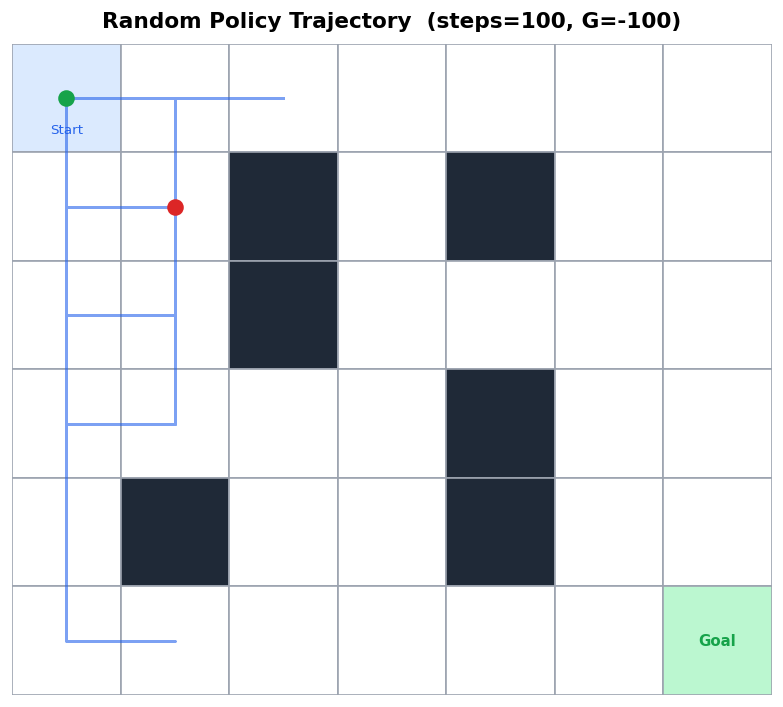

✓ Saved: figures/02_random_trajectory.png


In [7]:
# Visualize a single trajectory
env.reset()
traj, G = run_episode(env, random_policy, max_steps=100)

fig, ax = render_grid(env, title=f'Random Policy Trajectory  (steps={len(traj)}, G={G:.0f})')

# Draw trajectory path
xs = [env.start[1] + 0.5]
ys = [env.nrows - 1 - env.start[0] + 0.5]
for state, action, reward in traj:
    xs.append(state[1] + 0.5)
    ys.append(env.nrows - 1 - state[0] + 0.5)

ax.plot(xs, ys, color=BLUE, lw=1.5, alpha=0.6, zorder=5)
ax.scatter(xs[0],  ys[0],  color=GREEN, s=80, zorder=6)
ax.scatter(xs[-1], ys[-1], color=RED,   s=80, zorder=6)

plt.savefig('figures/02_random_trajectory.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/02_random_trajectory.png')

<a id='4'></a>
## 4. Policy — What Should the Agent Do?

A **policy** $\pi$ maps states to actions:
- **Deterministic:** $a = \pi(s)$
- **Stochastic:** $\pi(a \mid s) = P[A_t = a \mid S_t = s]$

We implement a **greedy policy** — at each state, always move toward the goal
using the shortest Manhattan distance. This is the "human intuition" policy,
not learned from experience. In later lectures we'll derive it automatically.

=== Greedy Policy vs Random Policy ===
                        Steps (mean)   Return G (mean)
Random policy                  232.5            -231.6
Greedy policy                   11.0             -10.0


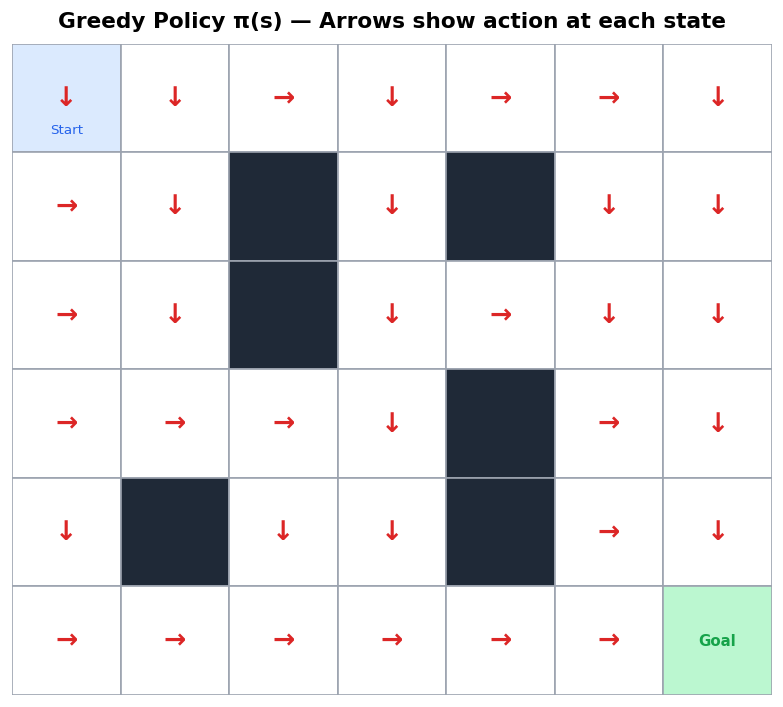

✓ Saved: figures/03_greedy_policy.png


In [8]:
def manhattan_greedy_policy(state, env):
    """Greedy policy: pick action that minimizes Manhattan distance to goal.
    Breaks ties randomly.  Ignores walls (approximation).
    """
    best_actions = []
    best_dist    = float('inf')

    for action in range(env.N_ACTIONS):
        next_state = env.transition(state, action)
        dist = abs(next_state[0] - env.goal[0]) + abs(next_state[1] - env.goal[1])
        if dist < best_dist:
            best_dist    = dist
            best_actions = [action]
        elif dist == best_dist:
            best_actions.append(action)

    return np.random.choice(best_actions)


# Build the full policy map for visualization
greedy_policy_map = {
    s: manhattan_greedy_policy(s, env)
    for s in env.states
    if not env.is_terminal(s)
}

# Show how it compares to random
print('=== Greedy Policy vs Random Policy ===')
print(f'{"":20}  {"Steps (mean)": >14}  {"Return G (mean)": >16}')

for name, policy_fn in [
    ('Random policy',  random_policy),
    ('Greedy policy',  lambda s: manhattan_greedy_policy(s, env)),
]:
    results = [run_episode(env, policy_fn, max_steps=500) for _ in range(200)]
    steps   = [len(t) for t, _ in results]
    returns = [G for _, G in results]
    print(f'{name:20}  {np.mean(steps):>14.1f}  {np.mean(returns):>16.1f}')

fig, _ = render_grid(
    env, policy=greedy_policy_map,
    title='Greedy Policy π(s) — Arrows show action at each state'
)
plt.savefig('figures/03_greedy_policy.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/03_greedy_policy.png')

<a id='5'></a>
## 5. Value Function — How Good Is Each State?

The **value function** $v_\pi(s)$ is the expected total return starting from state $s$
and following policy $\pi$:

$$v_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s] = \mathbb{E}_\pi\left[\sum_{k=0}^{\infty} \gamma^k R_{t+k+1} \mid S_t = s\right]$$

We estimate this by **Monte Carlo** — run many episodes from each state and
average the returns. In Lecture 2 we'll compute it exactly using the Bellman equation.

The numbers in Silver's slide 32 are exactly $v_\pi(s)$ for the random policy with $\gamma = 1$.

Estimating value function for random policy (Monte Carlo)...
Estimating value function for greedy policy (Monte Carlo)...


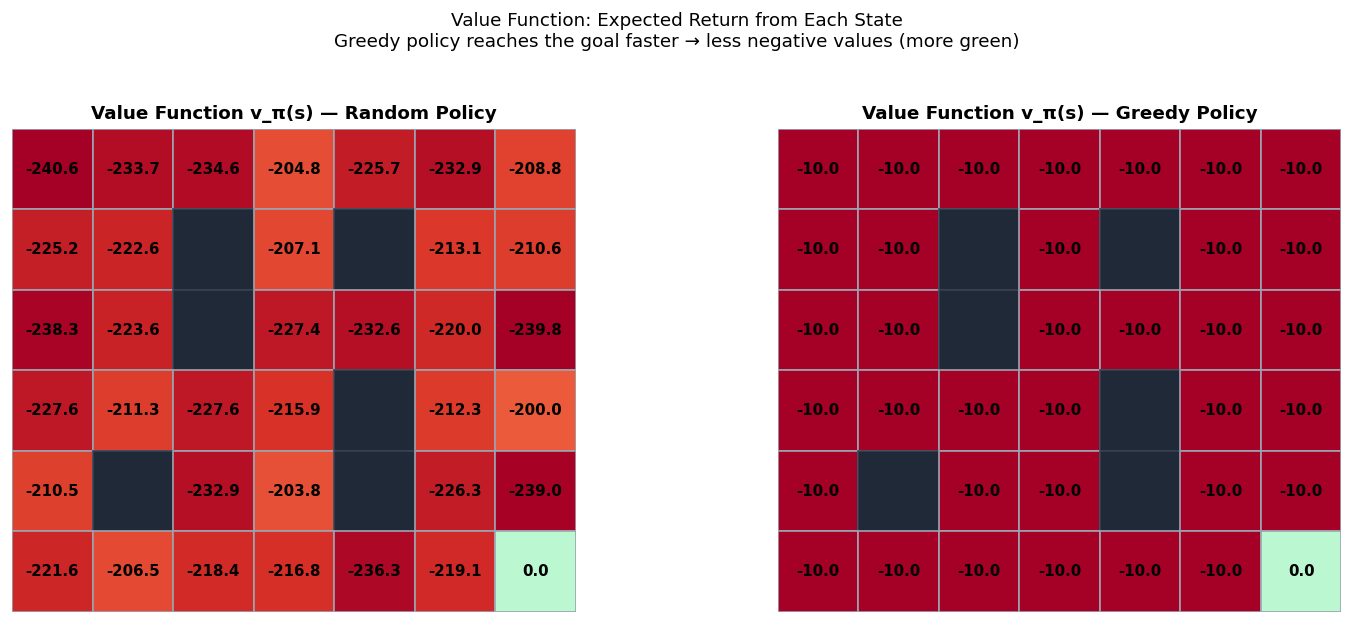

✓ Saved: figures/04_value_functions.png


In [9]:
def estimate_value_function(env, policy_fn, n_episodes=5000,
                             gamma=1.0, max_steps=500):
    """Estimate v_pi(s) for all states via Monte Carlo.

    For each state, run n_episodes episodes starting from that state
    and average the total discounted return.

    Returns dict: state -> estimated value.
    """
    values  = {s: [] for s in env.states}

    for _ in range(n_episodes):
        # Start from a random non-terminal state
        start = env.states[np.random.randint(env.n_states)]
        if env.is_terminal(start):
            continue

        # Run episode
        env.state   = start
        traj, G     = run_episode(env, policy_fn,
                                   max_steps=max_steps, gamma=gamma)
        values[start].append(G)

    # Average
    return {
        s: np.mean(v) if v else 0.0
        for s, v in values.items()
    }


print('Estimating value function for random policy (Monte Carlo)...')
v_random = estimate_value_function(env, random_policy, n_episodes=8000)

print('Estimating value function for greedy policy (Monte Carlo)...')
v_greedy = estimate_value_function(
    env, lambda s: manhattan_greedy_policy(s, env), n_episodes=8000
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, values, title in [
    (axes[0], v_random, 'Value Function v_π(s) — Random Policy'),
    (axes[1], v_greedy, 'Value Function v_π(s) — Greedy Policy'),
]:
    # Manually draw
    for r in range(env.nrows):
        for c in range(env.ncols):
            if env.grid[r, c] == 1:
                rect = plt.Rectangle((c, env.nrows-1-r), 1, 1,
                                      facecolor='#1f2937', edgecolor='#374151')
                ax.add_patch(rect)
            elif (r, c) == env.goal:
                rect = plt.Rectangle((c, env.nrows-1-r), 1, 1,
                                      facecolor='#bbf7d0', edgecolor='#9ca3af')
                ax.add_patch(rect)
                ax.text(c+0.5, env.nrows-1-r+0.5, '0.0',
                        ha='center', va='center', fontsize=9, fontweight='bold')
            else:
                v = values.get((r, c), 0.0)
                all_v = [vv for vv in values.values() if vv != 0]
                vmin  = min(all_v) if all_v else -1
                vmax  = 0
                norm  = (v - vmin) / (vmax - vmin + 1e-9)
                color = plt.cm.RdYlGn(norm)
                rect  = plt.Rectangle((c, env.nrows-1-r), 1, 1,
                                       facecolor=color, edgecolor='#9ca3af')
                ax.add_patch(rect)
                ax.text(c+0.5, env.nrows-1-r+0.5, f'{v:.1f}',
                        ha='center', va='center', fontsize=9, fontweight='bold')

    ax.set_xlim(0, env.ncols)
    ax.set_ylim(0, env.nrows)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle(
    'Value Function: Expected Return from Each State\n'
    'Greedy policy reaches the goal faster → less negative values (more green)',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig('figures/04_value_functions.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/04_value_functions.png')

<a id='6'></a>
## 6. The Discount Factor γ

The discount factor $\gamma \in [0, 1]$ controls how much the agent values future rewards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \ldots$$

- **γ = 0**: agent only cares about immediate reward — completely myopic
- **γ = 1**: agent values all future rewards equally — far-sighted
- **γ = 0.9**: reward 10 steps away is worth only $0.9^{10} \approx 35\%$ of immediate reward

In the gridworld with reward = -1 per step, lower γ makes distant states
look less bad — the agent is less motivated to reach the goal quickly.

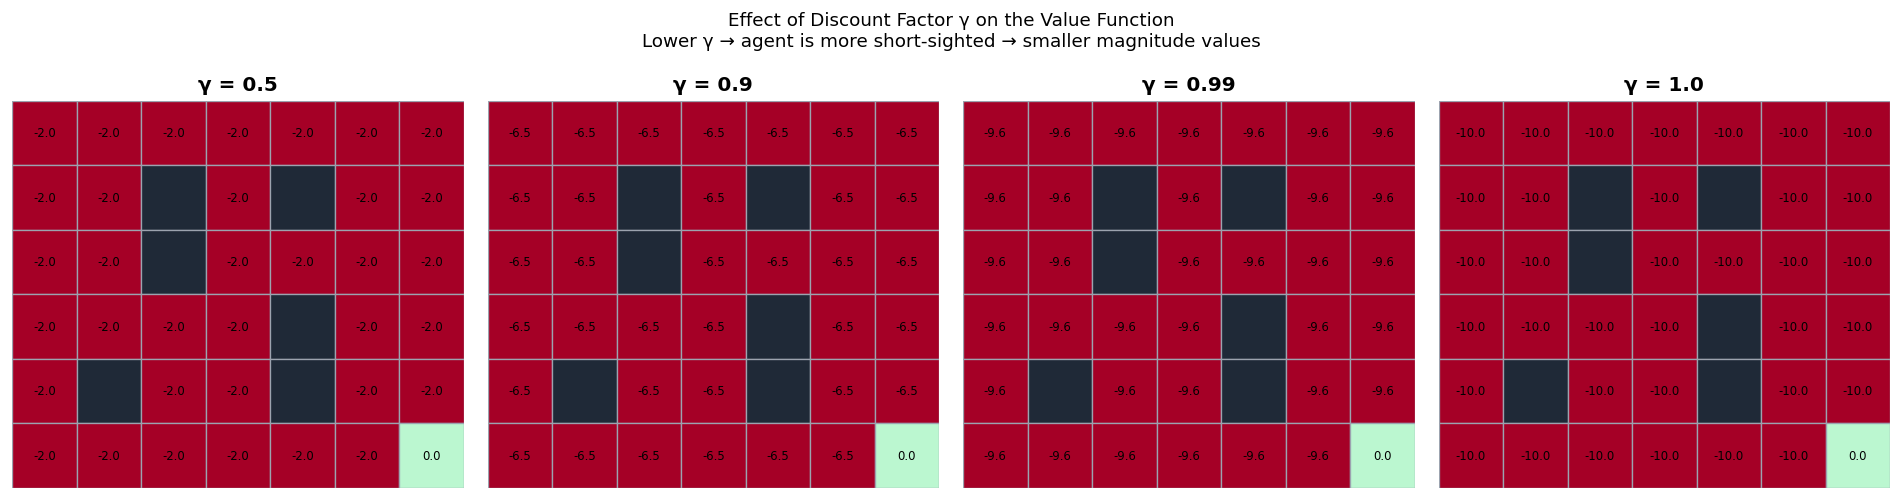

✓ Saved: figures/05_discount_factor.png


In [10]:
gammas = [0.5, 0.9, 0.99, 1.0]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
policy_fn = lambda s: manhattan_greedy_policy(s, env)

for ax, gamma in zip(axes, gammas):
    v = estimate_value_function(env, policy_fn, n_episodes=3000, gamma=gamma)

    for r in range(env.nrows):
        for c in range(env.ncols):
            if env.grid[r, c] == 1:
                color = '#1f2937'
            elif (r, c) == env.goal:
                color = '#bbf7d0'
            else:
                val   = v.get((r,c), 0.0)
                all_v = [vv for vv in v.values()]
                vmin  = min(all_v)
                norm  = (val - vmin) / (0 - vmin + 1e-9)
                color = plt.cm.RdYlGn(np.clip(norm, 0, 1))
            rect = plt.Rectangle((c, env.nrows-1-r), 1, 1,
                                   facecolor=color, edgecolor='#9ca3af', lw=0.8)
            ax.add_patch(rect)
            if env.grid[r, c] == 0:
                val = v.get((r,c), 0.0)
                ax.text(c+0.5, env.nrows-1-r+0.5, f'{val:.1f}',
                        ha='center', va='center', fontsize=7)

    ax.set_xlim(0, env.ncols)
    ax.set_ylim(0, env.nrows)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'γ = {gamma}', fontsize=12, fontweight='bold')

plt.suptitle(
    'Effect of Discount Factor γ on the Value Function\n'
    'Lower γ → agent is more short-sighted → smaller magnitude values',
    fontsize=11, y=1.03
)
plt.tight_layout()
plt.savefig('figures/05_discount_factor.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/05_discount_factor.png')

<a id='7'></a>
## 7. Exploration vs. Exploitation

The fundamental tension in RL — from Silver's slides:

| | Exploitation | Exploration |
|--|-------------|-------------|
| Restaurant | Go to your favourite | Try a new one |
| Ad selection | Show the best known ad | Show a new ad |
| Oil drilling | Drill at best known location | Drill somewhere new |

The **ε-greedy** policy interpolates between the two:
- With probability $1-\varepsilon$: exploit (take the greedy action)
- With probability $\varepsilon$: explore (take a random action)

We'll build full bandit algorithms in Lecture 09. Here we just visualize the tradeoff.

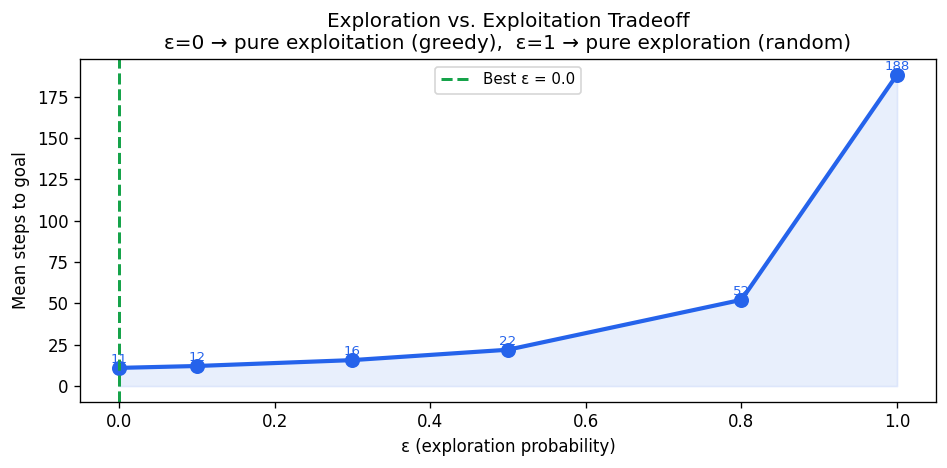

✓ Saved: figures/06_exploration_exploitation.png
Best ε: 0.0 (11 mean steps)


In [11]:
def epsilon_greedy_policy(state, env, epsilon):
    """ε-greedy policy: explore with prob ε, exploit otherwise."""
    if np.random.random() < epsilon:
        return np.random.randint(env.N_ACTIONS)             # explore
    return manhattan_greedy_policy(state, env)              # exploit


epsilons  = [0.0, 0.1, 0.3, 0.5, 0.8, 1.0]
n_trials  = 500
mean_steps = []

for eps in epsilons:
    policy_fn = lambda s, e=eps: epsilon_greedy_policy(s, env, e)
    results   = [run_episode(env, policy_fn, max_steps=300) for _ in range(n_trials)]
    steps     = [len(t) for t, _ in results]
    mean_steps.append(np.mean(steps))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epsilons, mean_steps, 'o-', color=BLUE, lw=2.5, ms=8)
ax.axvline(epsilons[np.argmin(mean_steps)], color=GREEN, ls='--', lw=1.8,
           label=f'Best ε = {epsilons[np.argmin(mean_steps)]}')
ax.fill_between(epsilons, mean_steps, alpha=0.1, color=BLUE)
ax.set_xlabel('ε (exploration probability)')
ax.set_ylabel('Mean steps to goal')
ax.set_title(
    'Exploration vs. Exploitation Tradeoff\n'
    'ε=0 → pure exploitation (greedy),  ε=1 → pure exploration (random)'
)
ax.legend(fontsize=9)
for eps, steps in zip(epsilons, mean_steps):
    ax.annotate(f'{steps:.0f}', xy=(eps, steps), xytext=(eps, steps+3),
                ha='center', fontsize=8, color=BLUE)

plt.tight_layout()
plt.savefig('figures/06_exploration_exploitation.png', bbox_inches='tight')
plt.show()
print('✓ Saved: figures/06_exploration_exploitation.png')
print(f'Best ε: {epsilons[np.argmin(mean_steps)]} ({min(mean_steps):.0f} mean steps)')

<a id='8'></a>
## 8. Key Takeaways

| Concept | What to Remember |
|---------|------------------|
| **Agent-environment loop** | Agent takes action → gets reward + next state → repeat |
| **Return G** | Total discounted future reward: $G_t = \sum_k \gamma^k R_{t+k+1}$ |
| **Markov property** | Future depends only on current state, not history |
| **Policy π** | Maps states to actions — the agent's behaviour |
| **Value function v_π** | Expected return from each state under policy π |
| **Discount γ** | Controls short-sightedness: γ=0 myopic, γ=1 far-sighted |
| **Exploration** | Try new things to find better rewards |
| **Exploitation** | Use known good actions to maximize immediate reward |

**What's next — Lecture 2:** We'll derive the value function analytically using the
**Bellman equation** instead of estimating it by simulation. This will let us compute
$v_\pi(s)$ exactly for any policy, and find the optimal value function $v^*(s)$.

---
*Source: David Silver, UCL Reinforcement Learning Course, Lecture 1*  
*Reference: Sutton & Barto (2018), Introduction to Reinforcement Learning, Chapter 1*